### Imports

In [743]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
import random

from sklearn.metrics import accuracy_score
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler

from private import REDACTED_EMAIL

In [744]:
start = time.time()
random.seed(42)
SHOW_PLOTS = True #Change this to True if you want to display all plots and tables

# I: Data Management

## A: Joining Data Sets

Creating an indicator for whether person was in followup, and then merging

In [745]:
baseline = pd.read_excel("C:/Users/micah/Downloads/Food_Waste/Epa_population_baseline_data.xlsx")
three_month = pd.read_excel("C:/Users/micah/Downloads/Food_Waste/Clean_Population_3_Month_Follow_Up.xlsx")
three_month.rename(columns={'3M_PAR_ID': 'par_id'}, inplace=True)
three_month['3M_FOLLOW_UP'] = 1
six_month = pd.read_excel("C:/Users/micah/Downloads/Food_Waste/EPA_Population_6_Month_Follow_up_June_3,_2026_16.03_No_emails.xlsx")
six_month.rename(columns={'6M_PAR_ID': 'par_id'}, inplace=True)
six_month['6M_FOLLOW_UP'] = 1 

In [746]:
## SOME PEOPLE ARE IN THE THREE MONTH AND NOT IN THE ORIGINAL ##
set(three_month['par_id']) - set(baseline['par_id'])

## Some of these are easy fixes or typos that I can just replace:
three_month['par_id'] = three_month['par_id'].replace('CHEFF0055', 'CHEF0055')
three_month['par_id'] = three_month['par_id'].replace(REDACTED_EMAIL, 'CHEF0026')

In [747]:
df1 = pd.merge(baseline, three_month, on='par_id', how='outer')
df = pd.merge(df1, six_month, on='par_id', how = 'outer')

Replacing null values in indicator column with 0's

In [748]:
df['3M_FOLLOW_UP'] = df["3M_FOLLOW_UP"].fillna(0)
df['6M_FOLLOW_UP'] = df['6M_FOLLOW_UP'].fillna(0)

These functions will be helpful later

In [749]:
def get_response_pct(df, col):
    return (
        df[col]
          .dropna()
          .astype(str)
          .str.split(r',\s*')
          .explode()
          .value_counts()
          / df[col].notna().sum()
          * 100
    )

def plot_onevar(df, col, title=None, tight = False, style = 'bar', pct = None):
    if not SHOW_PLOTS:
        return
    if style == 'pie':
        ax = get_response_pct(df, col).plot(kind=style, autopct=pct)
    else:
        ax = get_response_pct(df, col).plot(kind=style)        
    if title:
        ax.set_title(title)
    ax.set_ylabel('% of Respondents')
    if tight:
        plt.tight_layout()
    plt.show()

def counts_onevar(df, col, title = None, tight = False):
    if not SHOW_PLOTS:
        return
    ax = df[col].value_counts().plot(kind = 'bar')
    if title:
        ax.set_title(title)
    ax.set_ylabel('Number of Respondents')
    if tight:
        plt.tight_layout()
    plt.show()    

def make_response_df(series_3m, series_6m):
    if not SHOW_PLOTS:
        return
    response_df = pd.concat([series_3m, series_6m], axis=1).fillna(0)
    response_df.columns = ['3M', '6M']
    return response_df

def plot_responses(df, ylabel='% of Respondents', title=None, tight = False):
    if not SHOW_PLOTS:
        return
    ax = df.plot(kind='bar', color=['steelblue', 'orange'])
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    if tight:
        plt.tight_layout()
    plt.show()

## B: Condensing Variables

Creating new dummy variables, groups 1 & 2 vs 3 & 4
Note: Some values are missing because they were probably miscoded in the original
<br>
<br>
Setting the 1's for learn to be if already familiar<br>
Setting the 1's for newskill to be strongly agree or agree<br>
Setting the 1's for confid to be 1 if very confident, 0 otherwise<br>
Setting the 1's for try to be 1 if very/somewhat likely

In [750]:
#Three for Learn
df['LEARN_BREAD_CONDENSE'] = (df['learn_bread_video_num'] > 2).astype(int)
df['LEARN_FV_CONDENSE'] = (df['learn_fv_video_num'] > 2).astype(int)
df['LEARN_GRAIN_CONDENSE'] = (df['learn_grain_video_num'] > 2).astype(int)

#Three for New Skill
df['NEWSKILL_BREAD_CONDENSE'] = (df['newskill_bread_video_num'] < 3).astype(int)
df['NEWSKILL_FV_CONDENSE'] = (df['newskill_fv_video_num'] < 3).astype(int)
df['NEWSKILL_GRAIN_CONDENSE'] = (df['newskill_grain_video_num'] < 3).astype(int)

#Three for Confidence
df['CONFID_BREAD_CONDENSE'] = (df['confid_grain_video_num'] == 1).astype(int)
df['CONFID_FV_CONDENSE'] = (df['confid_fv_video_num'] == 1).astype(int)
df['CONFID_GRAIN_CONDENSE'] = (df['confid_grain_video_num'] == 1).astype(int)

#Three for Try
df['TRY_BREAD_CONDENSE'] = (df['try_bread_video_num'] < 3).astype(int)
df['TRY_FV_CONDENSE'] = (df['try_fv_video_num'] < 3).astype(int)
df['TRY_GRAIN_CONDENSE'] = (df['try_grain_video_num'] < 3).astype(int)

newvars = ['LEARN_BREAD_CONDENSE', 'LEARN_FV_CONDENSE', 'LEARN_GRAIN_CONDENSE',
           'NEWSKILL_BREAD_CONDENSE', 'NEWSKILL_FV_CONDENSE', 'NEWSKILL_GRAIN_CONDENSE',
           'CONFID_BREAD_CONDENSE', 'CONFID_FV_CONDENSE', 'CONFID_GRAIN_CONDENSE',
           'TRY_BREAD_CONDENSE', 'TRY_FV_CONDENSE', 'TRY_GRAIN_CONDENSE']

Creating Averages and Sums:
<br>
<br>
Dropping 5's as well.<br>
I found that there were 74 rows where at least one of the values was a 5.

In [751]:
varlist = ['newskill_bread_video_num', 'newskill_fv_video_num','newskill_grain_video_num', 'confid_bread_video_num', 
           "confid_fv_video_num", 'confid_grain_video_num', 'try_bread_video_num', 'try_fv_video_num', 'try_grain_video_num']

mask = df.loc[df[varlist].isin([5]).any(axis=1)]
mask[varlist]
#There are 74 people who answered 5 to at least 1 question
df = df.loc[df[varlist].isin([1,2,3,4]).any(axis = 1)]
df = df.copy()

Averages First:

In [752]:
df['BREAD_AVG'] = df[['newskill_bread_video_num', 'confid_bread_video_num', 'try_bread_video_num']].sum(axis = 1) / 3
df['FV_AVG'] = df[['newskill_fv_video_num', 'confid_fv_video_num', 'try_fv_video_num']].sum(axis = 1) / 3
df['GRAIN_AVG'] = df[['newskill_grain_video_num', 'confid_grain_video_num', 'try_grain_video_num']].sum(axis = 1) / 3

Then Sums:

In [753]:
df['BREAD_SUM'] = df[['newskill_bread_video_num', 'confid_bread_video_num', 'try_bread_video_num']].sum(axis = 1)
df['FV_SUM'] = df[['newskill_fv_video_num', 'confid_fv_video_num', 'try_fv_video_num']].sum(axis = 1)
df['GRAIN_SUM'] = df[['newskill_grain_video_num', 'confid_grain_video_num', 'try_grain_video_num']].sum(axis = 1)

(Note: They have the same distribution since they are always in proportion)

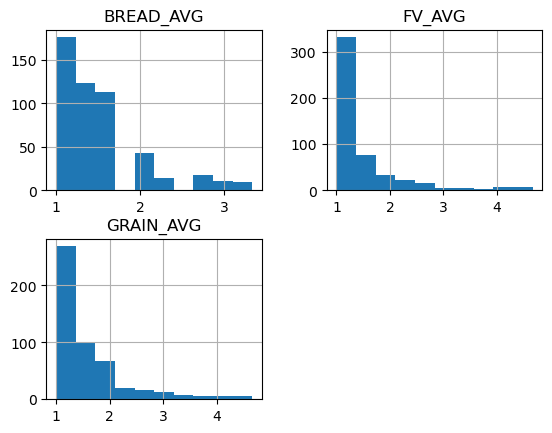

In [754]:
averages = ['BREAD_AVG', 'FV_AVG', 'GRAIN_AVG']
if SHOW_PLOTS:
    df[averages].hist()

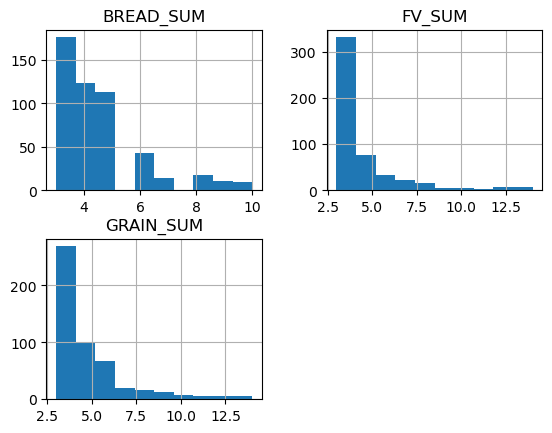

In [755]:
sums = ['BREAD_SUM', 'FV_SUM', 'GRAIN_SUM']
if SHOW_PLOTS:
    df[sums].hist()

Making average and sum variables across all videos:

In [756]:
df['VIDEO_AVG_NCT'] = df[['BREAD_AVG', 'FV_AVG', 'GRAIN_AVG']].sum(axis = 1) / 3
df['VIDEO_SUM_NCT'] = df[['BREAD_SUM', 'FV_SUM', 'GRAIN_SUM']].sum(axis = 1)

Now I am mapping importance_try and importance_nottry to a binary variable in each column.

In [757]:
try_cols = ['importance_try_1', 'importance_try_2', 'importance_try_3', 'importance_try_4',
 'importance_try_5', 'importance_try_6', 'importance_try_7', 'importance_try_8',
 'importance_try_9', 'importance_try_10', 'importance_try_11', 'importance_try_12',
 'importance_try_13', 'importance_try_14', 'importance_try_15', 'importance_try_16']
df[try_cols] = df[try_cols].notna().astype(int)

In [758]:
not_try_cols = ['important_nottry_1', 'important_nottry_2', 'important_nottry_3', 'important_nottry_4',
 'important_nottry_5', 'important_nottry_6', 'important_nottry_7', 'important_nottry_8',
 'important_nottry_9', 'important_nottry_10', 'important_nottry_11', 'important_nottry_12',
 'important_nottry_13', 'important_nottry_14', 'important_nottry_15', 'important_nottry_16']
df[not_try_cols] = df[not_try_cols].notna().astype(int)

In [759]:
df['try_sum'] = df[try_cols].sum(axis = 1)
df['not_try_sum'] = df[not_try_cols].sum(axis = 1)

In [760]:
df['try_sum'].unique()

array([3])

In [761]:
df['not_try_sum'].unique()

array([3])

Looks like everyone still in the dataset chose exactly three options for try and not try.

Now plotting these to see which are most frequent:

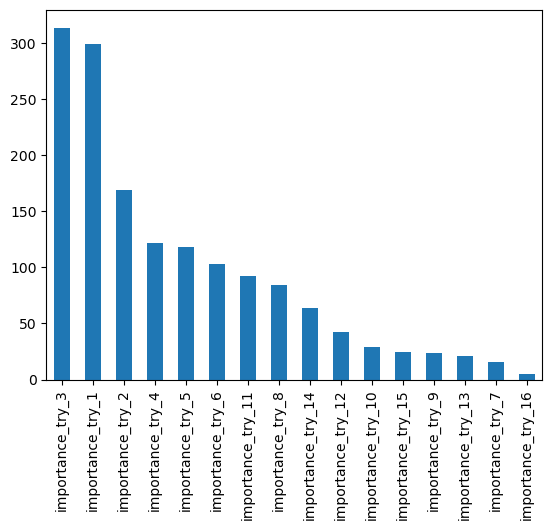

In [762]:
df[try_cols].sum().sort_values(ascending=False).plot(kind='bar');

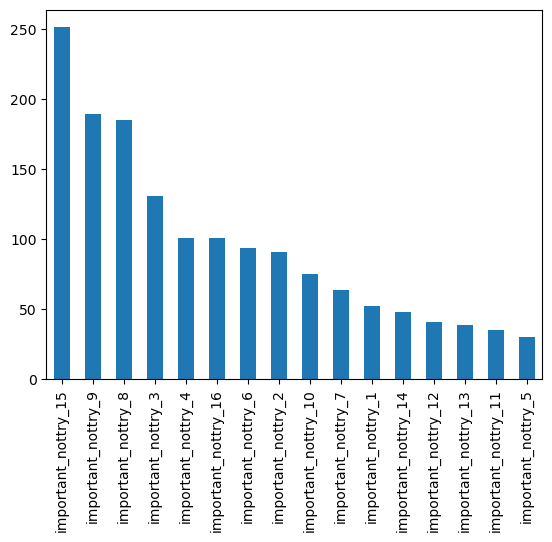

In [763]:
df[not_try_cols].sum().sort_values(ascending=False).plot(kind='bar');

Counts for 3M_ Yes Repeat, 3M_REAS_NOREPEAT, 3M_REAS_NOT_TRIED are straightforward since each row only includes 1.
<br>
For 3M_IMPORTANCE_TRY and 3M_IMPORTANT_NOTTRY, people put in up to 3.

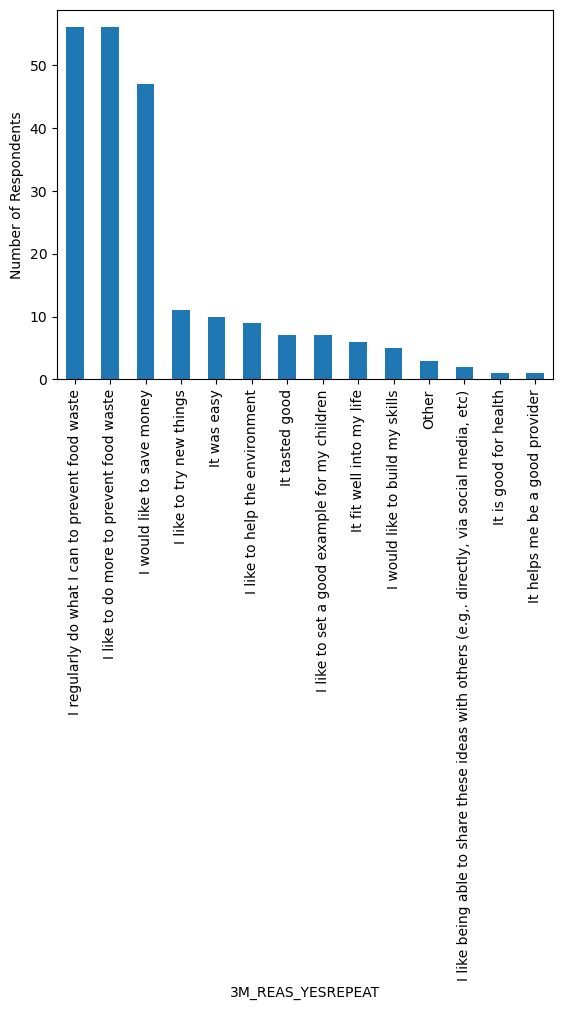

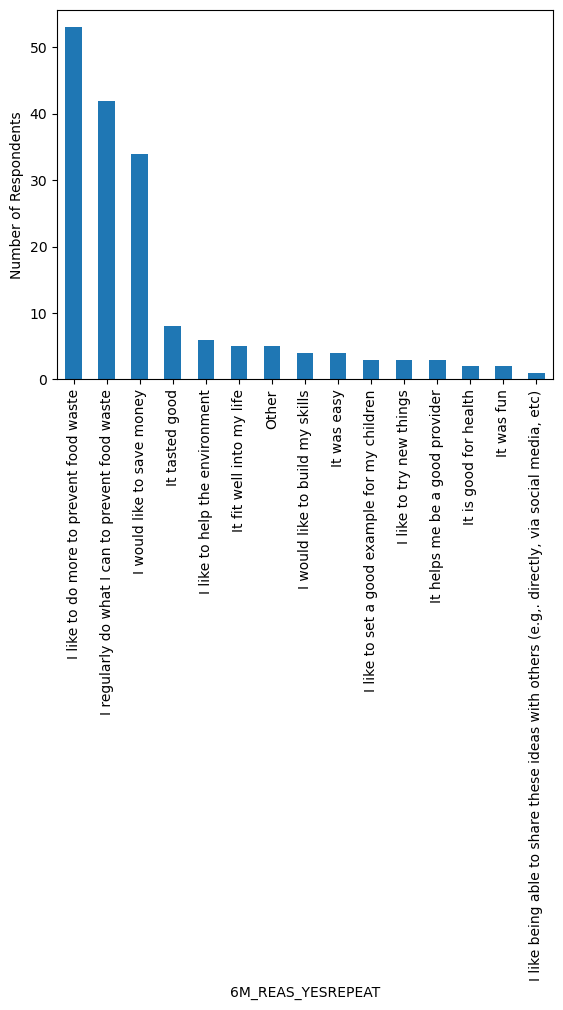

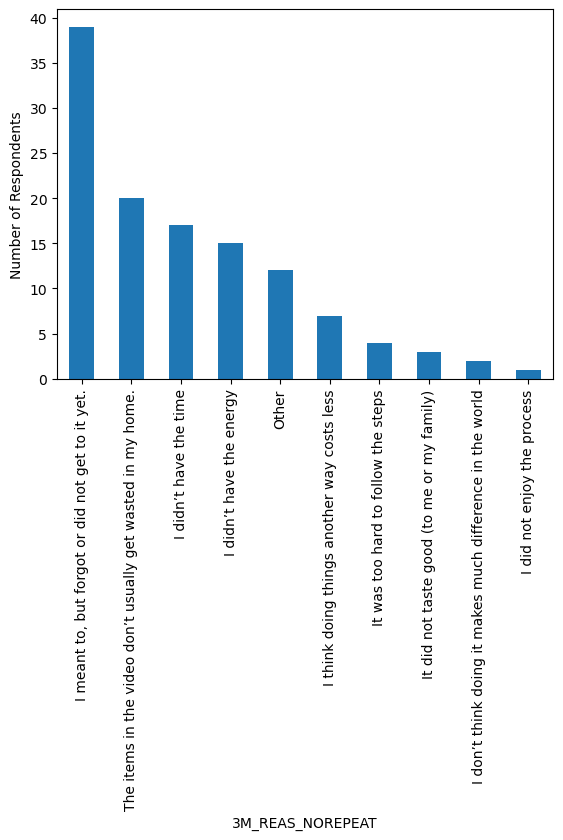

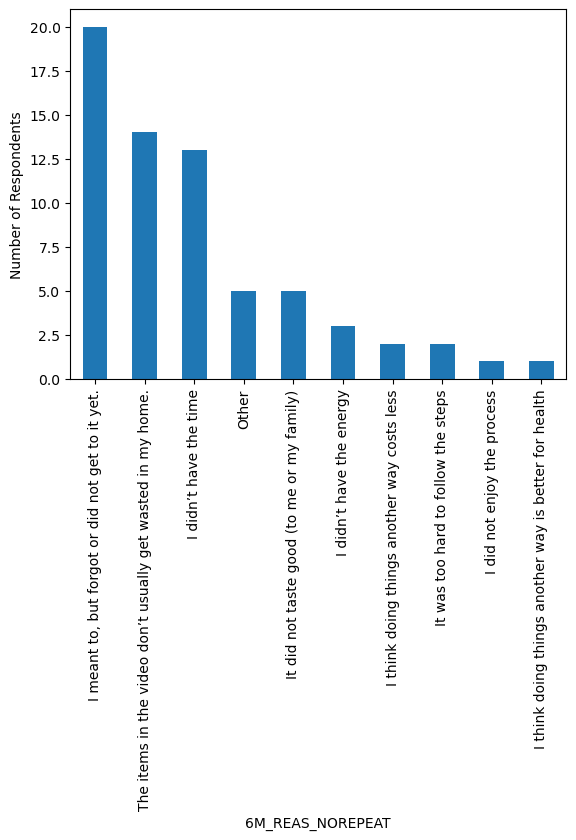

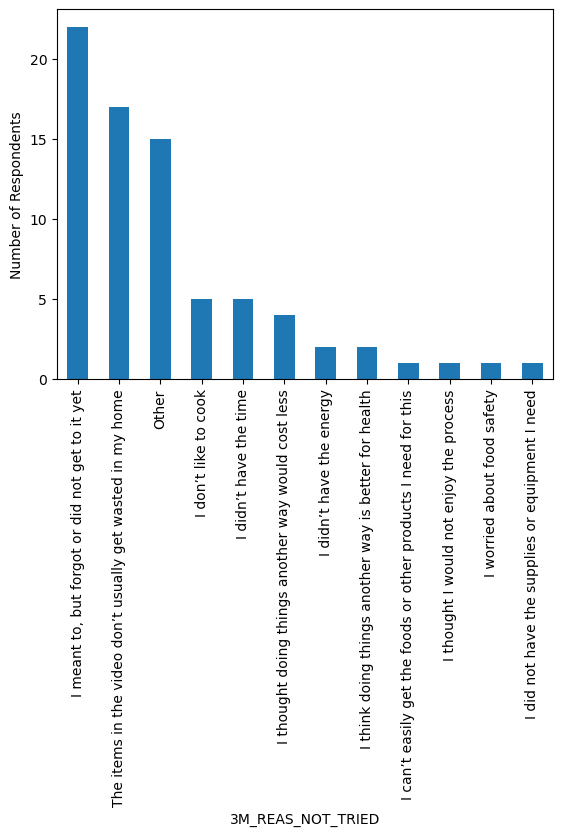

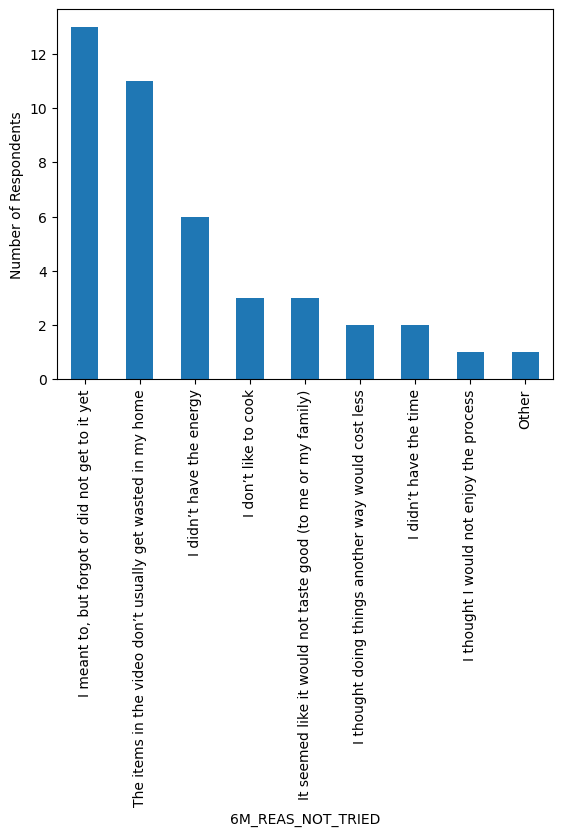

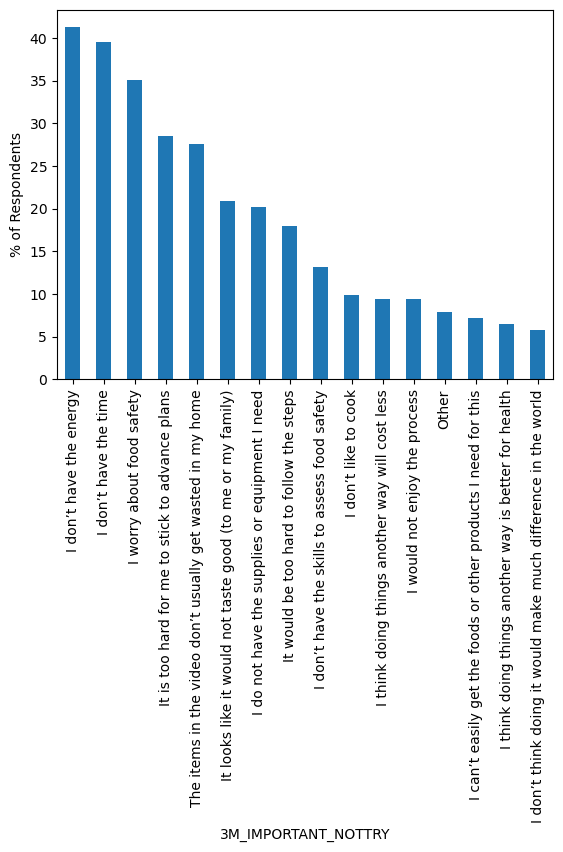

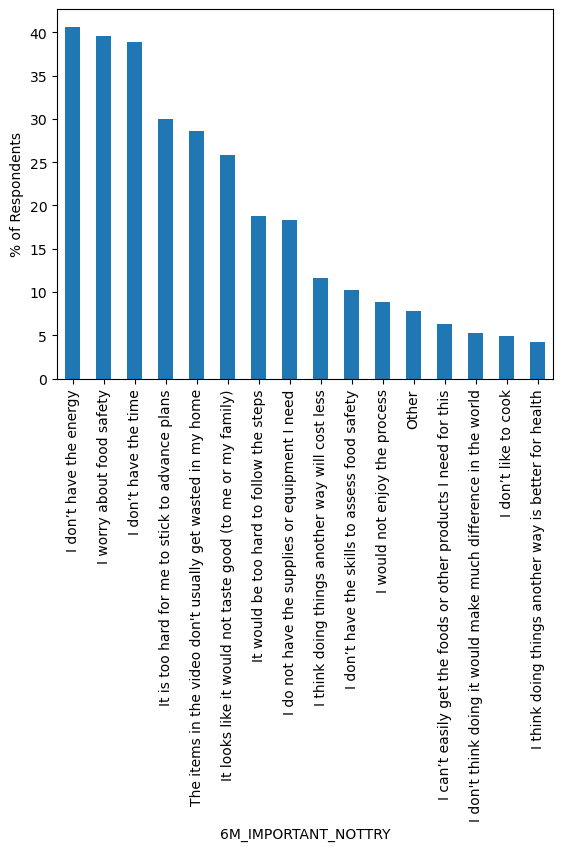

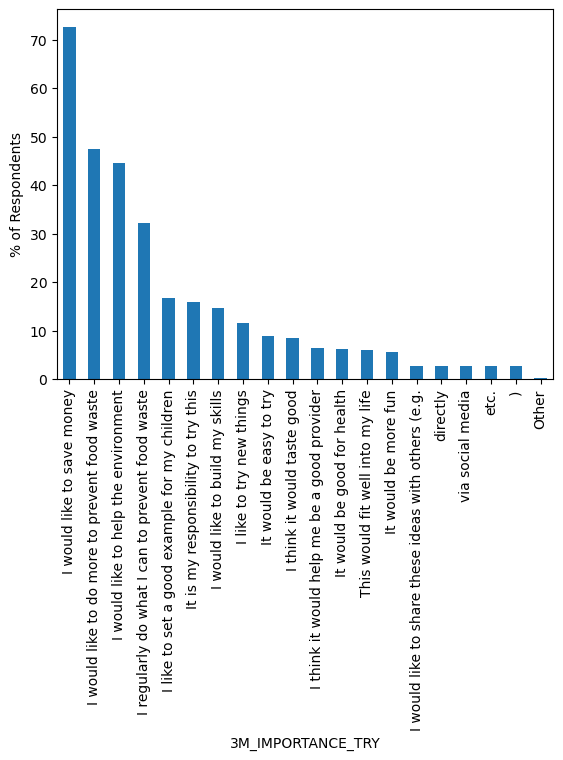

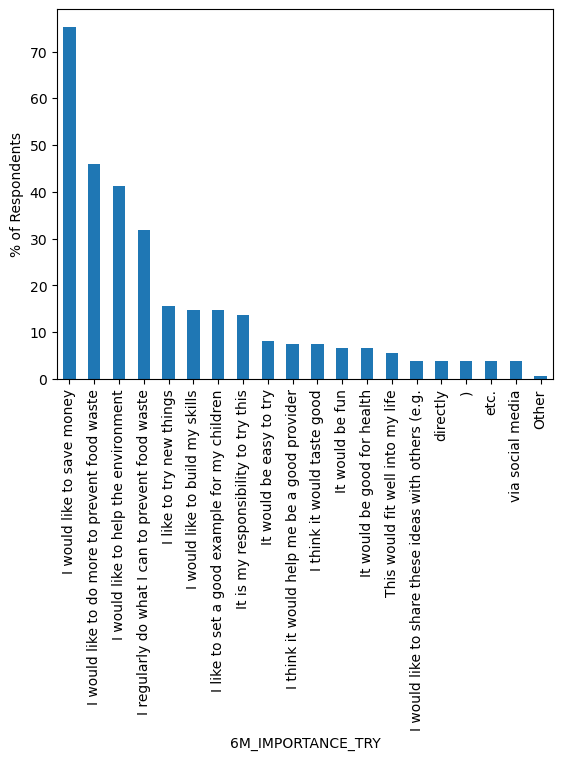

In [764]:
#Graphs for each of these variables showing the frequencies.

counts_onevar(df, '3M_REAS_YESREPEAT')
counts_onevar(df, '6M_REAS_YESREPEAT')
counts_onevar(df, '3M_REAS_NOREPEAT')
counts_onevar(df, '6M_REAS_NOREPEAT')
counts_onevar(df, '3M_REAS_NOT_TRIED')
counts_onevar(df, '6M_REAS_NOT_TRIED')

#Note: these four are more precisely split up further along in the notebook
plot_onevar(df, '3M_IMPORTANT_NOTTRY')
plot_onevar(df, '6M_IMPORTANT_NOTTRY')
plot_onevar(df, '3M_IMPORTANCE_TRY')
plot_onevar(df, '6M_IMPORTANCE_TRY')

Now I'm changing agree to disagree and disagree to agree for both "fw_approach_4" and "fw_approach_7"

In [765]:
#print(f"Before the swap: \n{df['fw_approach_4'].value_counts()}")
df['fw_approach_4'] = df['fw_approach_4'].replace({'Disagree':'Agree', 'Agree':'Disagree'})
#print(f"After the swap: \n{df['fw_approach_4'].value_counts()}")

In [766]:
#print(f"Before the swap: \n{df['fw_approach_7'].value_counts()}")
df['fw_approach_7'] = df['fw_approach_7'].replace({'Disagree':'Agree', 'Agree':'Disagree'})
#print(f"After the swap: \n{df['fw_approach_7'].value_counts()}")

I am mapping all of the agrees to 1's, neutral's to 0, and disagree to -1

In [767]:
fw_approaches = ['fw_approach_1', 'fw_approach_2', 'fw_approach_3',
                 'fw_approach_4', 'fw_approach_5', 'fw_approach_6', 'fw_approach_7',]
mapping = {'Agree': 1, 'Neutral': 0, 'Disagree': -1}
df[fw_approaches] = df[fw_approaches].apply(lambda x: x.map(mapping))

Creating:<br>
1) FW_APPROACH_AVG which averages across all 7 fw approach columns <br>
2) FW_APPROACH_CULINARYGOOD_INDEX which averages across fw_approach_1, fw_approach_2, and fw_approach_5 <br>
3) FW_APPROACH_CHEFHELPS_INDEX which averages across fw_approach_3, fw_approach_6, fw_approach_7

In [768]:
df['FW_APPROACH_AVG'] = df[fw_approaches].sum(axis = 1) / 7
df['FW_APPROACH_CULINARYGOOD_INDEX'] = df[['fw_approach_1', 'fw_approach_2', 'fw_approach_5']].sum(axis = 1) / 3
df['FW_APPROACH_CHEFHELPS_INDEX'] = df[['fw_approach_3', 'fw_approach_6', 'fw_approach_7']].sum(axis = 1) / 3

# II: Calculations, Tables, and Display

Note: For age, the ranges on the table are different from those we actually have data on.<br> For instance we don’t have 35-44 only 30-39 and 40-49 so there’s no way to say which bucket each person falls into. <br>
I have adjusted it for now to work with what we have.

In [769]:
table_data = {
    "Category": [
        "Age 19-29", "Age 30-39", "Age 40-49", "Age 50-59", "Age 60+",
        "Gender: Male", "Gender: Female", "Gender: Non-binary or other", "Gender: Prefer not to say",
        "Hispanic or Latino/Latina (Y/N)",
        "Race: American Indian or Alaska Native", "Race: Asian", "Race: Black or African American",
        "Race: Native Hawaiian or Pacific Islander", "Race: White", "Race: Other", "Race: Prefer not to answer",
        "Household income: <$10,000", "Household income: $10,000-$24,999", "Household income: $25,000-$49,999",
        "Household income: $50,000-$74,999", "Household income: $75,000-$99,999", "Household income: $100,000+",
        "Household income: Don't know or prefer not to say",
        "Employment status: Full time", "Employment status: Part time", "Employment status: Unemployed",
        "Employment status: Retired", "Employment status: Prefer not to say",
        "Household size <16: 0", "Household size <16: 1-2", "Household size <16: 3+",  
        "Household size >16: 1", "Household size >16: 2", "Household size >16: 3+",
        "Education: Less than 12th grade", "Education: High school graduate or GED", "Education: Some college",
        "Education: College graduate", "Education: Graduate degree", "Education: Trade or Technical School"
    ],
    "Baseline and post-video survey": [None] * 41,
    "3 months post-video": [None] * 41,
    "6 months post-video": [None] * 41,
}

desc_table = pd.DataFrame(table_data)

Starting to fill in the data:

In [770]:
##AGE ROWS
age_counts = df['age'].value_counts()
age_counts['60+'] = age_counts.pop('60 or older') #Had to add as a fix to get Age 60+ row to fill in 
age_counts['19-29'] = age_counts.pop('19-21') + age_counts.pop('22-29')


age_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'age'].value_counts()
age_counts_3M['60+'] = age_counts_3M.pop('60 or older') #Had to add as a fix to get Age 60+ row to fill in 
age_counts_3M['19-29'] = age_counts_3M.pop('19-21') + age_counts_3M.pop('22-29')


age_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'age'].value_counts()
age_counts_6M['60+'] = age_counts_6M.pop('60 or older') #Had to add as a fix to get Age 60+ row to fill in 
age_counts_6M['19-29'] = age_counts_6M.pop('19-21') + age_counts_6M.pop('22-29')

desc_table.loc[desc_table['Category'].str.startswith('Age'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Age'), 'Category'].str.replace('Age ', '').map(age_counts)
)


desc_table.loc[desc_table['Category'].str.startswith('Age'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Age'), 'Category'].str.replace('Age ', '').map(age_counts_3M)
)


desc_table.loc[desc_table['Category'].str.startswith('Age'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Age'), 'Category'].str.replace('Age ', '').map(age_counts_6M)
)


In [771]:
##Gender and Race Rows:

#Gender:
gender_counts = df['gender'].value_counts()
gender_counts['Non-binary or other'] = gender_counts.pop('Non-binary') #Had to add as a fix to get Non-Binary -> Non-Binary or Other 

gender_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'gender'].value_counts()
gender_counts_3M['Non-binary or other'] = gender_counts_3M.pop("Non-binary") #Had to add as a fix to get Non-Binary -> Non-Binary or Other 

gender_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'gender'].value_counts()
gender_counts_6M['Non-binary or other'] = gender_counts_6M.pop("Non-binary") #Had to add as a fix to get Non-Binary -> Non-Binary or Other 


desc_table.loc[desc_table['Category'].str.startswith('Gender:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Gender:'), 'Category'].str.replace('Gender:', '').str.strip().map(gender_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Gender:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Gender:'), 'Category'].str.replace('Gender:', '').str.strip().map(gender_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Gender:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Gender:'), 'Category'].str.replace('Gender:', '').str.strip().map(gender_counts_6M)
)

#There is nobody in the survey who did not say gender. So I am hardcoding it to 0.

desc_table.loc[desc_table['Category'] == 'Gender: Prefer not to say', 'Baseline and post-video survey'] = 0

desc_table.loc[desc_table['Category'] == 'Gender: Prefer not to say', '3 months post-video'] = 0

desc_table.loc[desc_table['Category'] == 'Gender: Prefer not to say', '6 months post-video'] = 0




#Race:
race_counts = df[['race_1', 'race_2', 'race_3', 'race_4', 'race_5', 'race_6', 'race_7']].stack().value_counts()
race_counts['Asian'] = race_counts.pop('Asia')
race_counts['Other'] = race_counts.pop('I identify as')

race_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, ['race_1', 'race_2', 'race_3', 'race_4', 'race_5', 'race_6', 'race_7']].stack().value_counts()
race_counts_3M['Asian'] = race_counts_3M.pop('Asia')
race_counts_3M['Other'] = race_counts_3M.pop('I identify as')

race_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, ['race_1', 'race_2', 'race_6', 'race_4', 'race_5', 'race_6', 'race_7']].stack().value_counts()
race_counts_6M['Asian'] = race_counts_6M.pop('Asia')
race_counts_6M['Other'] = race_counts_6M.pop('I identify as')


desc_table.loc[desc_table['Category'].str.startswith('Race:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Race:'), 'Category'].str.replace('Race:', '').str.strip().map(race_counts)
)
desc_table.loc[desc_table['Category'] == 'Race: Native Hawaiian or Pacific Islander', 'Baseline and post-video survey'] = 0 #There are none in this group


desc_table.loc[desc_table['Category'].str.startswith('Race:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Race:'), 'Category'].str.replace('Race:', '').str.strip().map(race_counts_3M)
)
desc_table.loc[desc_table['Category'] == 'Race: Native Hawaiian or Pacific Islander', '3 months post-video'] = 0 #There are none in this group

desc_table.loc[desc_table['Category'].str.startswith('Race:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Race:'), 'Category'].str.replace('Race:', '').str.strip().map(race_counts_6M)
)
desc_table.loc[desc_table['Category'] == 'Race: Native Hawaiian or Pacific Islander', '6 months post-video'] = 0 #There are none in this group
desc_table.loc[desc_table['Category'] == 'Race: Black or African American', '6 months post-video'] = 0 #There are none in this group


#Hispanic:
hispanic_counts = df['ethnic'].value_counts()

hispanic_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'ethnic'].value_counts()

hispanic_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'ethnic'].value_counts()


desc_table.loc[desc_table['Category'] == 'Hispanic or Latino/Latina (Y/N)', 'Baseline and post-video survey'] = hispanic_counts.get('Yes', 0)
desc_table.loc[desc_table['Category'] == 'Hispanic or Latino/Latina (Y/N)', '3 months post-video'] = hispanic_counts_3M.get('Yes', 0)
desc_table.loc[desc_table['Category'] == 'Hispanic or Latino/Latina (Y/N)', '6 months post-video'] = hispanic_counts_6M.get('Yes', 0)

In [772]:
#Household income:

inc_counts = df['income'].value_counts() 
inc_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'income'].value_counts()
inc_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'income'].value_counts()

desc_table.loc[desc_table['Category'].str.startswith('Household income:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household income:'), 'Category'].str.replace('Household income:', '').str.strip().map(inc_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Household income:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household income:'), 'Category'].str.replace('Household income:', '').str.strip().map(inc_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Household income:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household income:'), 'Category'].str.replace('Household income:', '').str.strip().map(inc_counts_6M)
)

#Employment Status:
emp_counts = df['employ'].value_counts() 
emp_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'employ'].value_counts()
emp_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'employ'].value_counts()

desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), 'Category'].str.replace('Employment status:', '').str.strip().map(emp_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), 'Category'].str.replace('Employment status:', '').str.strip().map(emp_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Employment status:'), 'Category'].str.replace('Employment status:', '').str.strip().map(emp_counts_6M)
)


In [773]:
#Under 16:
df['hh_size_1'].unique()
#list of unique values: array([2, 0, 3, 1, 4, 'Na', 'Zero', 6, 'o', 'zero', 'O', 5], dtype=object)
#first, I need to recode some values. I will map Na -> 0, Zero -> 0, o -> 0, zero -> 0, and O - > 0
df['hh_size_1'] = df['hh_size_1'].replace({'Na': 0, 'Zero': 0, 'zero': 0, 'o': 0, 'O': 0})

#Buckets for children under 16: 0, 1-2, 3+

conditions = [df['hh_size_1'] == 0, df['hh_size_1'].between(1, 2), df['hh_size_1'] > 2]
choices = ['0', '1-2', '3+']
df['hh_size_1'] = np.select(conditions, choices, default='0')

C:\Users\micah\AppData\Local\Temp\ipykernel_26600\1593710990.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['hh_size_1'] = df['hh_size_1'].replace({'Na': 0, 'Zero': 0, 'zero': 0, 'o': 0, 'O': 0})


In [774]:
#Over 16:
df['hh_size_2'].unique()
#list of unique values: array([3, 2, 0, 5, 1, 'Na', 4, 'One', 'two', 'Q', 'Zero', 'I ', 7],dtype=object)
df['hh_size_2'] = df['hh_size_2'].replace({'Na': 0, 'Zero': 0, 'One': 1, 'I ': 1, 'two': 2}) #No idea what to do with 'Q'
#Since question says "including you", I am going to map 0 to 1, since that's the only thing it could mean
df['hh_size_2'] = df['hh_size_2'].replace({0:1})
df = df[df['hh_size_2'] != "Q"]
#dropping rows with Q because there's no good place to put them
df['hh_size_2'].value_counts()


#Buckets for household over 16:
conditions = [df['hh_size_2'] == 1, df['hh_size_2'] == 2, df['hh_size_2'] > 2]
choices = ['1', '2', '3+']
df['hh_size_2'] = np.select(conditions, choices, default='1')

In [775]:
#Education:
educ_counts = df['educ'].value_counts() 
educ_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'educ'].value_counts()
educ_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'educ'].value_counts()

desc_table.loc[desc_table['Category'].str.startswith('Education:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Education:'), 'Category'].str.replace('Education:', '').str.strip().map(educ_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Education:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Education:'), 'Category'].str.replace('Education:', '').str.strip().map(educ_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Education:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Education:'), 'Category'].str.replace('Education:', '').str.strip().map(educ_counts_6M)
)

#Household Size 1 (Under 16):

hh_size_1_counts = df['hh_size_1'].value_counts()
hh_size_1_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'hh_size_1'].value_counts()
hh_size_1_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'hh_size_1'].value_counts()

desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), 'Category'].str.replace('Household size <16:', '').str.strip().map(hh_size_1_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), 'Category'].str.replace('Household size <16:', '').str.strip().map(hh_size_1_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size <16:'), 'Category'].str.replace('Household size <16:', '').str.strip().map(hh_size_1_counts_6M)
)


#Household Size 2 (Over 16):
hh_size_2_counts = df['hh_size_2'].value_counts()
hh_size_2_counts_3M = df.loc[df['3M_FOLLOW_UP'] == 1, 'hh_size_2'].value_counts()
hh_size_2_counts_6M = df.loc[df['6M_FOLLOW_UP'] == 1, 'hh_size_2'].value_counts()

desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), 'Baseline and post-video survey'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), 'Category'].str.replace('Household size >16:', '').str.strip().map(hh_size_2_counts)
)

desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), '3 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), 'Category'].str.replace('Household size >16:', '').str.strip().map(hh_size_2_counts_3M)
)

desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), '6 months post-video'] = (
    desc_table.loc[desc_table['Category'].str.startswith('Household size >16:'), 'Category'].str.replace('Household size >16:', '').str.strip().map(hh_size_2_counts_6M)
)

#Food Security: There is no survey data about specifically food insecurity

In [776]:
totals = {
    'Baseline and post-video survey': len(df),
    '3 months post-video': df['3M_FOLLOW_UP'].sum(),
    '6 months post-video': df['6M_FOLLOW_UP'].sum(),
}

for col, n in totals.items():
    desc_table[col] = desc_table[col].apply(
        lambda x: f"{int(x)} ({x/n*100:.2f}%)" if pd.notna(x) else None
    )

In [777]:
if SHOW_PLOTS:
    display(desc_table)

,Category,Baseline and post-video survey,3 months post-video,6 months post-video
0,Age 19-29,61 (12.03%),50 (12.05%),36 (12.63%)
1,Age 30-39,138 (27.22%),114 (27.47%),84 (29.47%)
2,Age 40-49,135 (26.63%),108 (26.02%),75 (26.32%)
3,Age 50-59,89 (17.55%),78 (18.80%),53 (18.60%)
4,Age 60+,86 (16.96%),67 (16.14%),39 (13.68%)
5,Gender: Male,109 (21.50%),93 (22.41%),65 (22.81%)
6,Gender: Female,395 (77.91%),320 (77.11%),220 (77.19%)
7,Gender: Non-binary or other,5 (0.99%),4 (0.96%),2 (0.70%)
8,Gender: Prefer not to say,0 (0.00%),0 (0.00%),0 (0.00%)
9,Hispanic or Latino/Latina (Y/N),54 (10.65%),41 (9.88%),33 (11.58%)


Making the reasons for Importance_Try and REAS_YESREPEAT agree, also the reasons for REAS_NOT_TRIED and REAS_NOREPEAT

First I checked to see if there were wording differences between the 3 and 6 month datasets

In [778]:
#print(set(df['6M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['3M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()))
# "It would be fun" in 6 mo, "It would be more fun" in 3 mo
df['6M_IMPORTANCE_TRY'] = df['6M_IMPORTANCE_TRY'].str.replace('It would be fun', 'It would be more fun')
#print(set(df['6M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['3M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()))
#done


#print(set(df['6M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()))
# "It was fun" in 6 mo and no equiv in 3 mo. So I am putting it into the "other" category
df['6M_REAS_YESREPEAT'] = df['6M_REAS_YESREPEAT'].str.replace('It was fun', 'Other')
#print(set(df['6M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()))
#done

#print(set(df['6M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()))
# I can't easily get the foods or other products I need for this in 3mo, I did not have the supplies or equipment I need in 3mo,
# I think doing things another way is better for health in 3mo, I worried about food safety in 3mo, It seemed like it would not taste good (to me or my family) in 6mo
# As far as I can tell these don't really have equivalents, so I'm putting them all into other
df['6M_REAS_NOT_TRIED'] = df['6M_REAS_NOT_TRIED'].str.replace('It seemed like it would not taste good (to me or my family)', 'Other')

#running a loop to change everything from 3m with no equiv in 6m to "other" 
to_replace = ["I can’t easily get the foods or other products I need for this","I did not have the supplies or equipment I need" , "I think doing things another way is better for health", "I worried about food safety"]
for option in to_replace:
    df['3M_REAS_NOT_TRIED'] = df['3M_REAS_NOT_TRIED'].str.replace(option, 'Other')

#print(set(df['6M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()))
#done


#print(set(df['6M_REAS_NOREPEAT'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_NOREPEAT'].str.split(',\s*').explode().unique()))
#I dont think doing it makes much difference in the world in 3mo, I think doing things another way is better for health in 6mo
#Putting each into other
df['3M_REAS_NOREPEAT'] = df['3M_REAS_NOREPEAT'].str.replace("I don’t think doing it makes much difference in the world", 'Other')
df['6M_REAS_NOREPEAT'] = df['6M_REAS_NOREPEAT'].str.replace('I think doing things another way is better for health', 'Other')
#print(set(df['6M_REAS_NOREPEAT'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_NOREPEAT'].str.split(',\s*').explode().unique()))
#done

First let's fix the IMPORTANCE_TRY and REAS_YESREPEAT columns:

In [779]:
#print((set(df['6M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_YESREPEAT'].str.split(',\s*').explode().unique())) ^
#(set(df['3M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_YESREPEAT'].str.split(',\s*').explode().unique())))
#The above says that we just fix the 3mo or the 6mo, and then apply the exact same changes to the other to fix both.

#print(set(df['6M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()))
#This would fit well into my life -> It fit well into my life
#I like being able to share these ideas with others (e.g -> I would like to share these ideas with others (e.g.  Should eventually fix so it's not split up so much
#I like to do more to prevent food waste -> I would like to do more to prevent food waste
#I like to help the environment -> I would like to help the environment
#I think it would help me be a good provider -> It helps me be a good provider
#I think it would taste good-> It tasted good
#It is good for health -> It would be good for health
#It is my responsibility to try this -> No equivalent (other)
#It was easy -> It would be easy to try
#It would be more fun -> No equivalent (other)

replacements = {
    'This would fit well into my life' : 'It fit well into my life',
    'I would like to do more to prevent food waste' : 'I like to do more to prevent food waste',
    'I would like to help the environment' : 'I like to help the environment',
    'I think it would help me be a good provider' : 'It helps me be a good provider',
    'I think it would taste good' : 'It tasted good',
    'It would be good for health' : 'It is good for health',
    'It is my responsibility to try this': 'Other',
    'It would be easy to try' : 'It was easy',
    'It would be more fun': 'Other'
}

#Fixing it in both columns
for col in ['3M_IMPORTANCE_TRY', '6M_IMPORTANCE_TRY']:
    for old, new in replacements.items():
        df[col] = df[col].str.replace(old, new, regex=False)

# Now fixing a certain statement that gets messed up when we try and split on the comma. 
# For all of them, I am just taking out the commas so it splits it up properly

df['3M_REAS_YESREPEAT'] = df['3M_REAS_YESREPEAT'].str.replace('I like being able to share these ideas with others (e.g,. directly, via social media, etc)', 'I would like to share these ideas with others (e.g. directly via social media etc)')
df['6M_REAS_YESREPEAT'] = df['6M_REAS_YESREPEAT'].str.replace('I like being able to share these ideas with others (e.g,. directly, via social media, etc)', 'I would like to share these ideas with others (e.g. directly via social media etc)')
df['3M_IMPORTANCE_TRY'] = df['3M_IMPORTANCE_TRY'].str.replace('I would like to share these ideas with others (e.g., directly, via social media, etc.,)', 'I would like to share these ideas with others (e.g. directly via social media etc)')
df['6M_IMPORTANCE_TRY'] = df['6M_IMPORTANCE_TRY'].str.replace('I would like to share these ideas with others (e.g., directly, via social media, etc.,)', 'I would like to share these ideas with others (e.g. directly via social media etc')

#print(set(df['6M_IMPORTANCE_TRY'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_YESREPEAT'].str.split(',\s*').explode().unique()))

Next the REAS_NOT_TRIED and REAS_NOREPEAT columns:

In [780]:
print((set(df['6M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_NOREPEAT'].str.split(',\s*').explode().unique())) ^
      (set(df['3M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['3M_REAS_NOREPEAT'].str.split(',\s*').explode().unique())))
#Again, we just have to figure it out on the 6mo or the 3mo and then the other will be the same

set(df['6M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_NOREPEAT'].str.split(',\s*').explode().unique())
#I did not enjoy the process -> I thought I would not enjoy the process
#I think doing things another way costs less -> I thought doing things another way would cost less
#I don't like to cook -> no equivalent(other)
#It did not taste good (to me or my family) -> no equivalent (other)
#It was too hard to follow the steps -> no equivalent (other)
#but forgot or did not get to it yet -> but forgot or did not get to it yet. I think I will leave this for now and change the whole thing upstream since it splits anyway
#The items in the video don't usually get wasted in my home - > The items in the video don't usually get wasted in my home.

#going from norepeat - > not tried
replacements = {
    'I did not enjoy the process' : 'I thought I would not enjoy the process',
    'I think doing things another way costs less' : 'I thought doing things another way would cost less',
    'It did not taste good (to me or my family)' : 'Other',
    'It was too hard to follow the steps' : 'Other',
    'The items in the video don’t usually get wasted in my home.' : 'The items in the video don’t usually get wasted in my home'
}

for col in ['3M_REAS_NOREPEAT', '6M_REAS_NOREPEAT']:
    for old, new in replacements.items():
        df[col] = df[col].str.replace(old, new, regex=False)

# I don't like to cook has to be done separately because not tried->norepeat
df['6M_REAS_NOT_TRIED'] = df['6M_REAS_NOT_TRIED'].str.replace('I don’t like to cook', 'Other')
df['3M_REAS_NOT_TRIED'] = df['3M_REAS_NOT_TRIED'].str.replace('I don’t like to cook', 'Other')

df['3M_REAS_NOT_TRIED'] = df['3M_REAS_NOT_TRIED'].str.replace('I meant to, but forgot or did not get to it yet', 'I meant to but forgot or did not get to it yet')
df['6M_REAS_NOT_TRIED'] = df['6M_REAS_NOT_TRIED'].str.replace('I meant to, but forgot or did not get to it yet', 'I meant to but forgot or did not get to it yet')
df['3M_REAS_NOREPEAT'] = df['3M_REAS_NOREPEAT'].str.replace('I meant to, but forgot or did not get to it yet.', 'I meant to but forgot or did not get to it yet')
df['6M_REAS_NOREPEAT'] = df['6M_REAS_NOREPEAT'].str.replace('I meant to, but forgot or did not get to it yet.', 'I meant to but forgot or did not get to it yet')


set(df['6M_REAS_NOT_TRIED'].str.split(',\s*').explode().unique()) ^ set(df['6M_REAS_NOREPEAT'].str.split(',\s*').explode().unique())

set()


set()

And here are a ton of visualizations

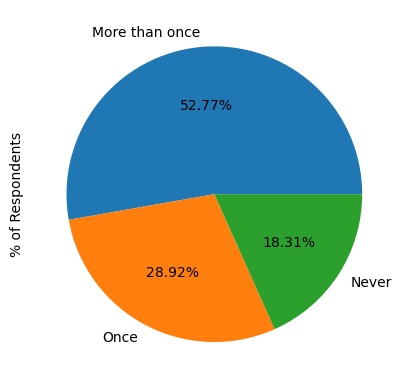

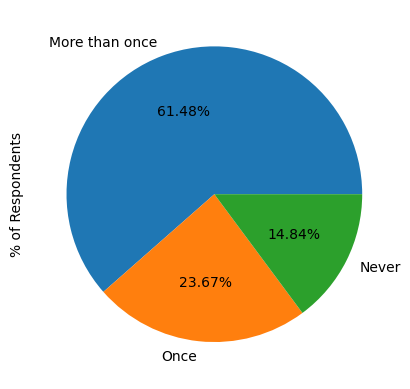

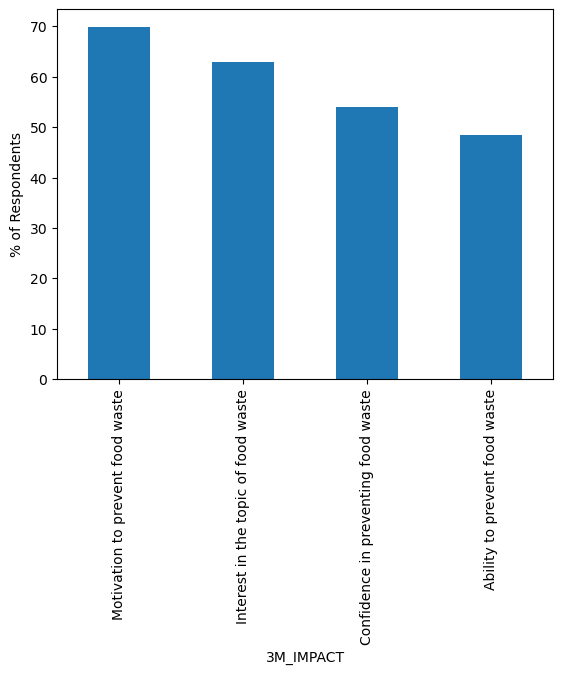

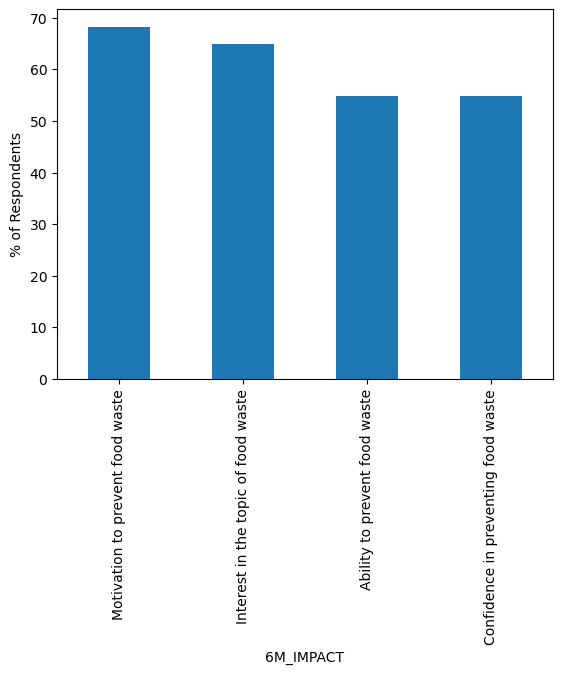

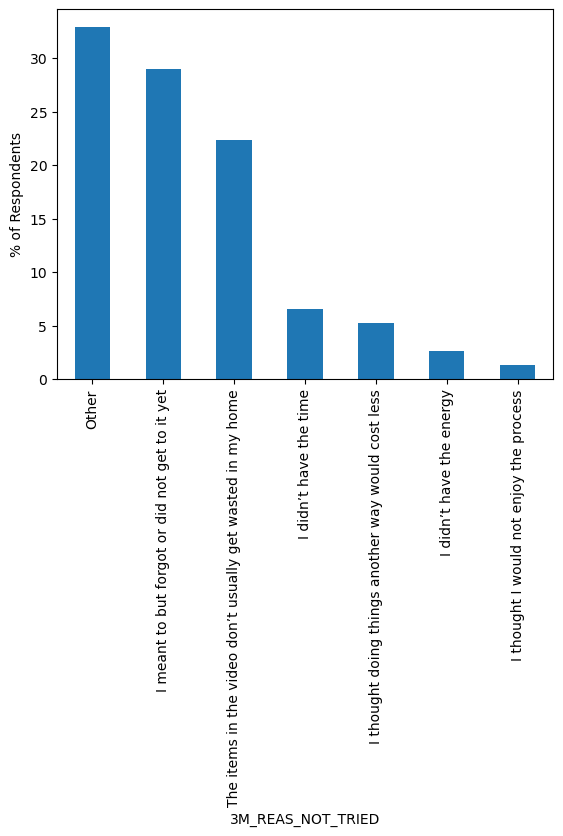

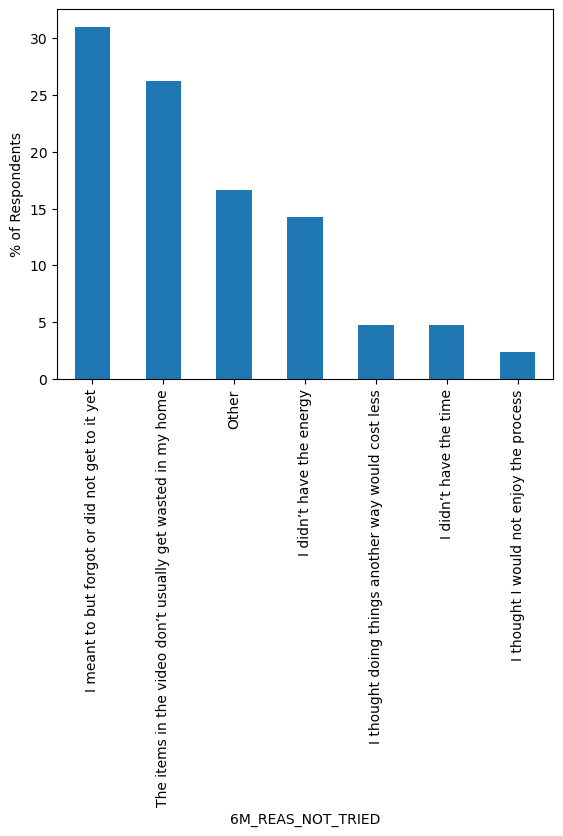

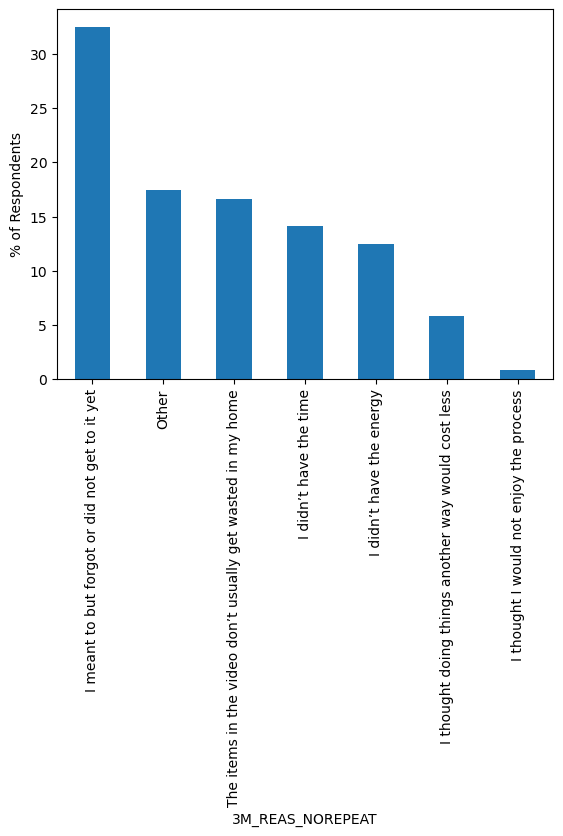

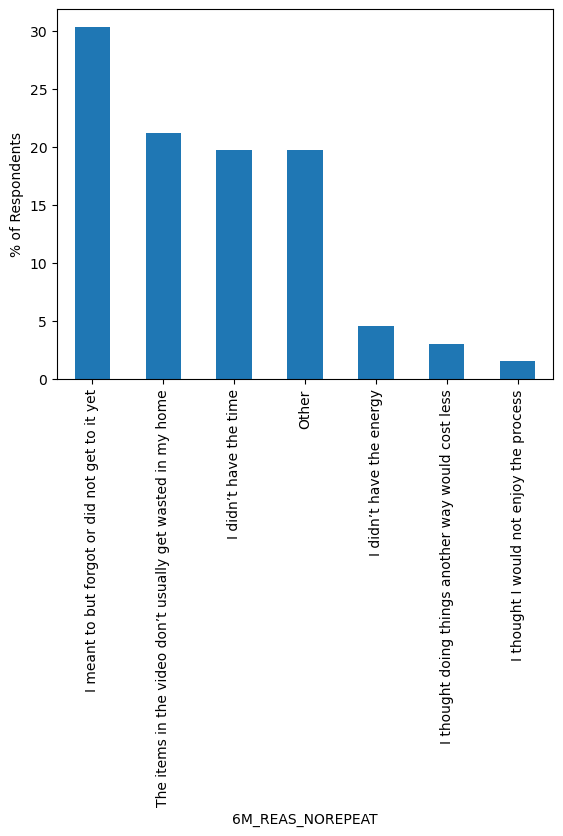

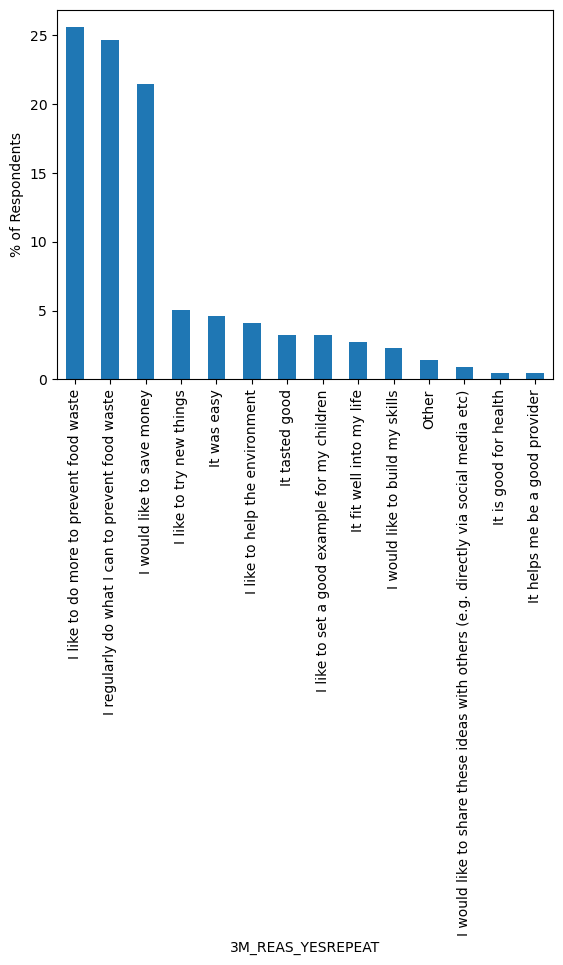

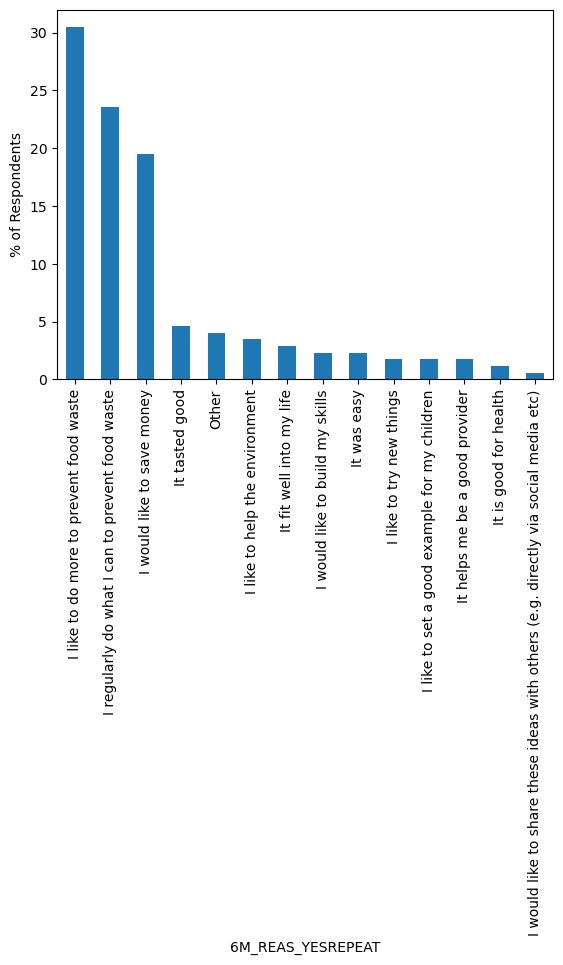

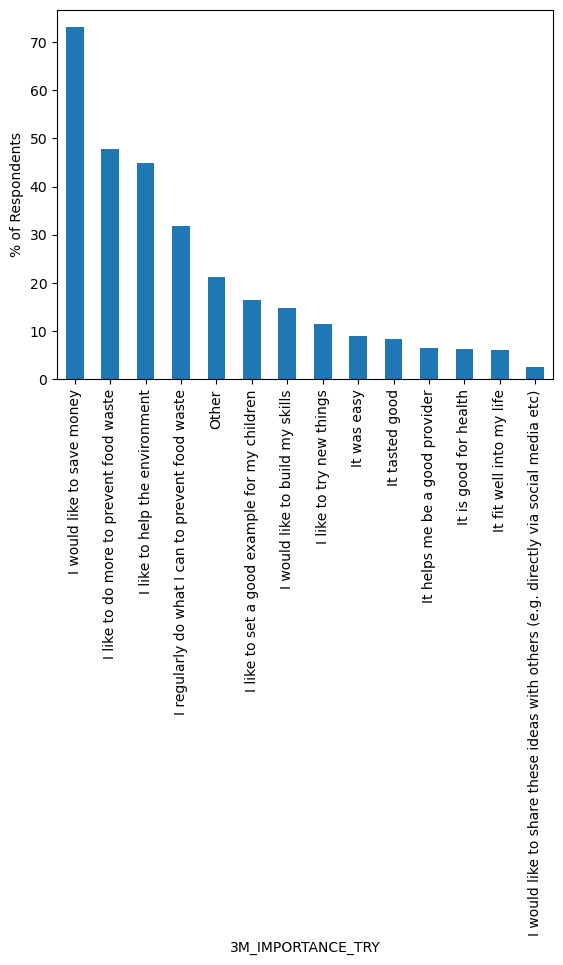

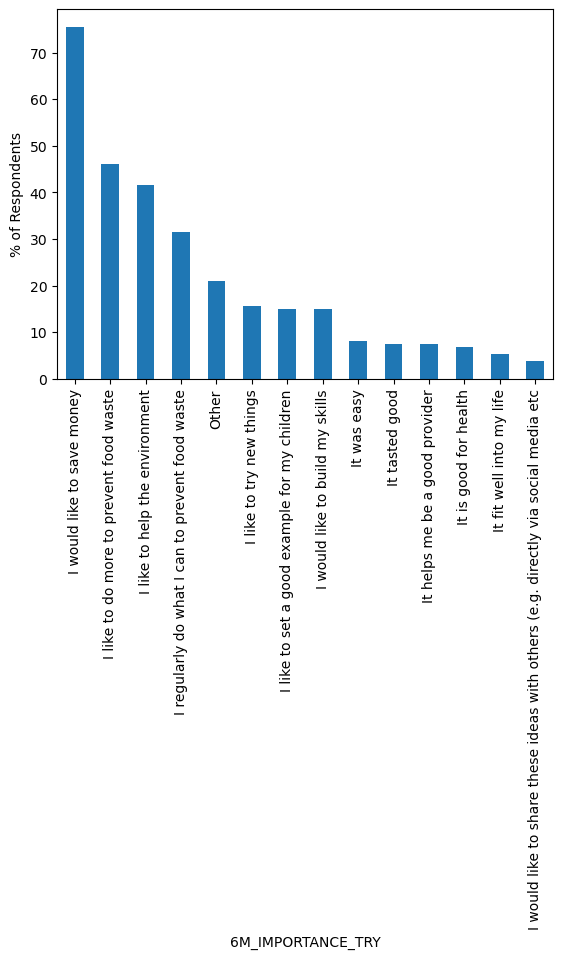

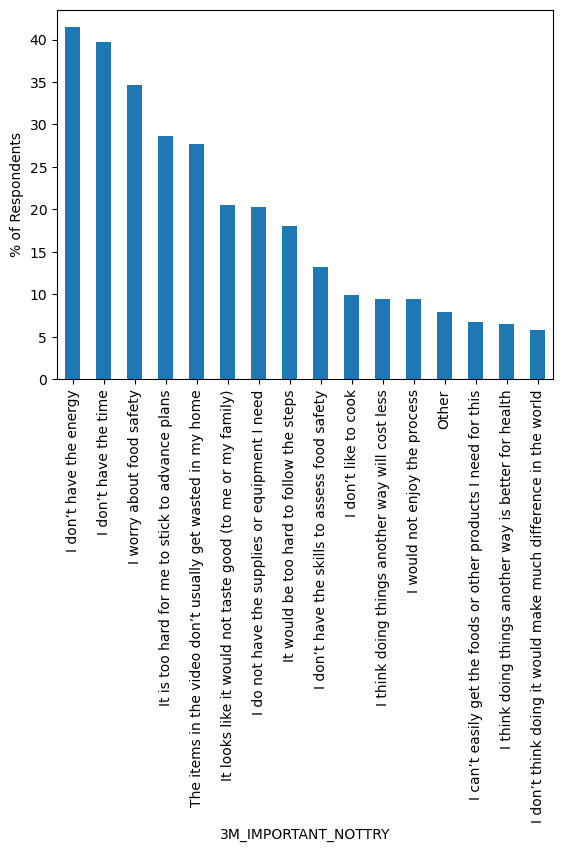

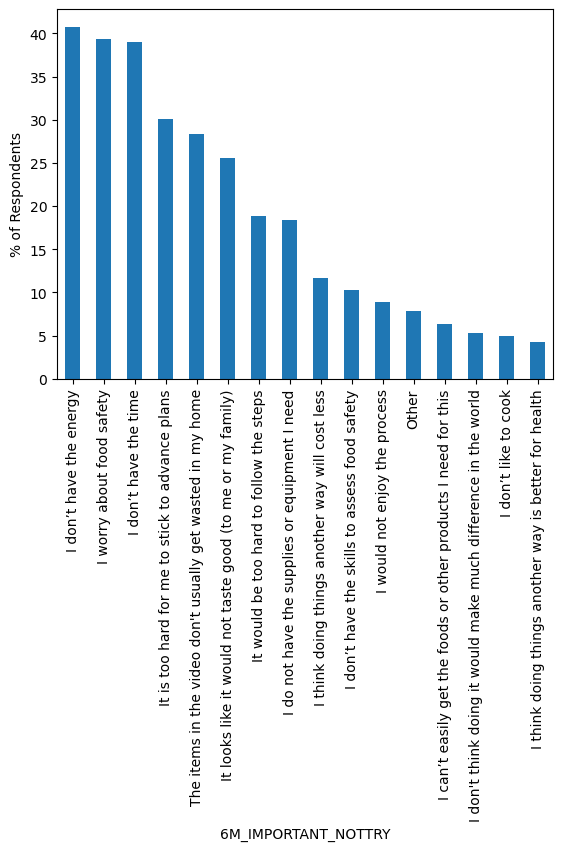

In [781]:
# Pie Chart with percentages for who actually tried:

plot_onevar(df, '3M_ACT_TRIED_YN', style = 'pie', pct = '%1.2f%%')
plot_onevar(df, '6M_ACT_TRIED_YN', style = 'pie', pct = '%1.2f%%')

# Percent who chose each response for impact:

plot_onevar(df, '3M_IMPACT')
plot_onevar(df, '6M_IMPACT')

# Percent who chose each reponse for reason not tried:

plot_onevar(df, '3M_REAS_NOT_TRIED')
plot_onevar(df, '6M_REAS_NOT_TRIED')

# Percent who chose each reponse for reason not repeated:

plot_onevar(df, '3M_REAS_NOREPEAT')
plot_onevar(df, '6M_REAS_NOREPEAT')

# Percent who chose each reponse for reason repeated:

plot_onevar(df, '3M_REAS_YESREPEAT')
plot_onevar(df, '6M_REAS_YESREPEAT')

#Percent who chose each reponse for importance_try:

plot_onevar(df, '3M_IMPORTANCE_TRY')
plot_onevar(df, '6M_IMPORTANCE_TRY')

#Percent who chose each reponse for important not_try:

plot_onevar(df, '3M_IMPORTANT_NOTTRY')
plot_onevar(df, '6M_IMPORTANT_NOTTRY')

### Comparing responses directly across periods:

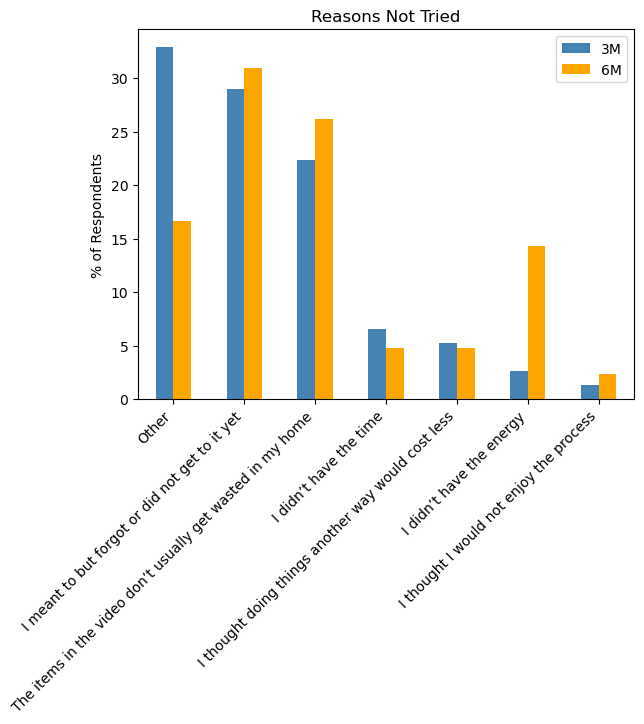

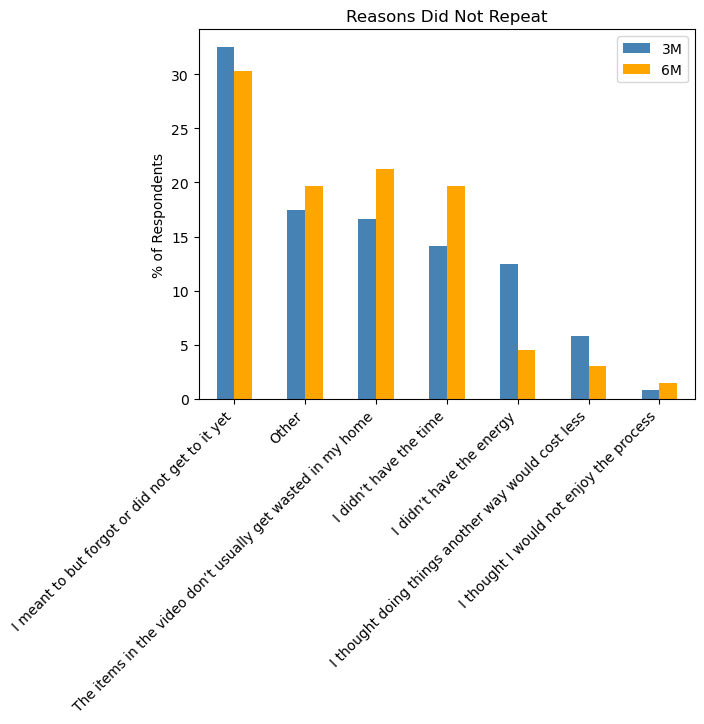

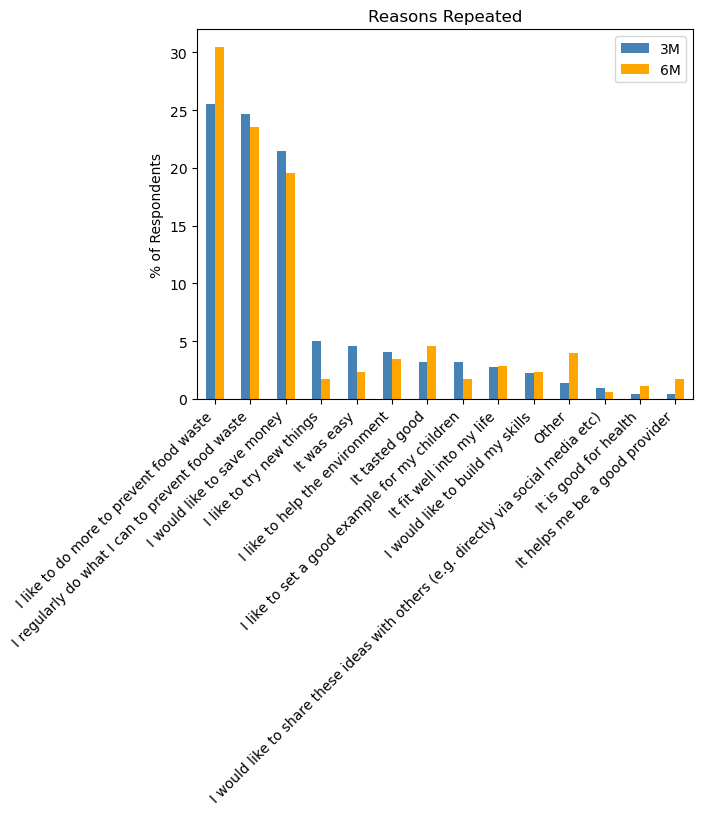

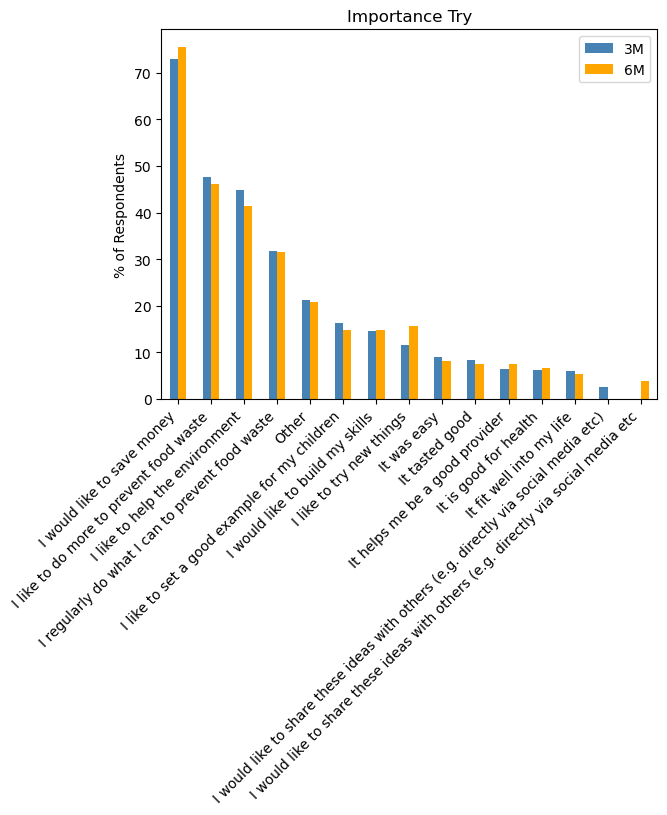

In [782]:
reas_not_try_pct_3 = get_response_pct(df, '3M_REAS_NOT_TRIED')
reas_not_try_pct_6 = get_response_pct(df, '6M_REAS_NOT_TRIED')
reas_norepeat_pct_3 = get_response_pct(df, '3M_REAS_NOREPEAT')
reas_norepeat_pct_6 = get_response_pct(df, '6M_REAS_NOREPEAT')
reas_repeat_pct_3 = get_response_pct(df, '3M_REAS_YESREPEAT')
reas_repeat_pct_6 = get_response_pct(df, '6M_REAS_YESREPEAT')
importance_try_3 = get_response_pct(df, '3M_IMPORTANCE_TRY')
importance_try_6 = get_response_pct(df, '6M_IMPORTANCE_TRY')


for s3, s6, title in [
    (reas_not_try_pct_3, reas_not_try_pct_6, 'Reasons Not Tried'),
    (reas_norepeat_pct_3, reas_norepeat_pct_6, 'Reasons Did Not Repeat'),
    (reas_repeat_pct_3, reas_repeat_pct_6, 'Reasons Repeated'),
    (importance_try_3, importance_try_6, 'Importance Try')
]:
    plot_responses(make_response_df(s3, s6), title=title)

### Time Series

In [783]:
#Time Series for Impact. Only two data points, not sure how useful it is
impactdf = pd.DataFrame()
total3M = df['3M_IMPACT'].notna().sum()
impactdf['3M_IMPACT'] = df['3M_IMPACT'].str.split(',\s*').explode().value_counts() / total3M * 100
total6m = df['6M_IMPACT'].notna().sum()
impactdf['6M_IMPACT'] = df['6M_IMPACT'].str.split(',\s*').explode().value_counts() / total3M * 100
# impactdf.T.plot(marker='o', figsize=(8,5))
# plt.ylabel('% of Respondents')
# plt.xlabel('Months since survey')
# plt.title('Impact Over Time')
# plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

#Time Series for ACT_TRIED
#Not sure what this illustrates. One would expect this result because you can't un-try, right? 
#Maybe the people who didn't try in the first place were less likely to answer the second survey?
tried_df = pd.DataFrame()
tried_3M = df['3M_ACT_TRIED_YN'].notna().sum()
tried_df['3M_ACT_TRIED_YN'] = df['3M_ACT_TRIED_YN'].str.split(',\s*').explode().value_counts() / tried_3M * 100
tried_6M = df['6M_ACT_TRIED_YN'].notna().sum()
tried_df['6M_ACT_TRIED_YN'] = df['6M_ACT_TRIED_YN'].str.split(',\s*').explode().value_counts() / tried_6M * 100
# tried_df.T.plot(marker='o', figsize=(8,5))
# plt.ylabel('% of Respondents')
# plt.xlabel('Months since survey')
# plt.title('Actually Tried Over Time')
# plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()



Checking to see whether people "un-tried" the recommendations

In [784]:
untry1 = (df['3M_ACT_TRIED_YN'] == 2) & (df['6M_ACT_TRIED_YN'].isin([0, 1])) #said they had tried >1 at 3 months, but at 6 months had only tried once or never
untry2 = (df['3M_ACT_TRIED_YN'] == 1) & (df['6M_ACT_TRIED_YN'] == 0) #said they had tried once at 3 months, and then said never tried at 6 months
df[untry1 | untry2] #since this is empty, we can conclude that nobody has un-tried recommendations

,var1,progress,finished,recordeddate,par_id,skill_level_1,skill_level_2,skill_level_3,skill_level_4,skill_level_5,...,BREAD_SUM,FV_SUM,GRAIN_SUM,VIDEO_AVG_NCT,VIDEO_SUM_NCT,try_sum,not_try_sum,FW_APPROACH_AVG,FW_APPROACH_CULINARYGOOD_INDEX,FW_APPROACH_CHEFHELPS_INDEX


In [785]:
end = time.time()
t1 = end - start
print(f"Total runtime of I and II is {t1} seconds")

Total runtime of I and II is 29.032594680786133 seconds


# III: Correlations and Regressions

In [786]:
start = time.time()

## A: Correlations

### First some cleaning up

In [787]:
Ordering = {'Once': 1, 'Never': 0, 'More than once': 2}
df['3M_ACT_TRIED_YN'] = df['3M_ACT_TRIED_YN'].map(Ordering)
df['6M_ACT_TRIED_YN'] = df['6M_ACT_TRIED_YN'].map(Ordering)

Adding Dummies

In [788]:
##Demographics

age_dummies = pd.get_dummies(
    df['age'],
    prefix='Age'
)

age_dummies['Age_19-29'] = age_dummies['Age_19-21'] + age_dummies['Age_22-29']
age_dummies = age_dummies.drop(columns=['Age_19-21', 'Age_22-29'])

income_dummies = pd.get_dummies(
    df['income'],
    prefix='Income'
)

educ_dummies = pd.get_dummies(
    df['educ'],
    prefix='Education'
)

gender_dummies = pd.get_dummies(
    df['gender'],
    prefix='Gender'
)

hh_size_1_dummies = pd.get_dummies(
    df['hh_size_1'],
    prefix = 'HH_Size_1'
)

hh_size_2_dummies = pd.get_dummies(
    df['hh_size_2'],
    prefix = 'HH_Size_2'
)

#Leaving out Household Size for now until we figure out what to do about it

In [789]:
Enjoy_cook_dummies = pd.get_dummies(
    df['enjoy_cook'],
    prefix='ENJOY_COOK'
)

Reduce_fw_dummies = pd.get_dummies(
    df['reduce_fw'],
    prefix='REDUCE_FW'
)

Impact_dummies_3m = df['3M_IMPACT'].str.get_dummies(sep=',')

In [790]:
print(df['3M_ACT_TRIED_YN'].corr(df['VIDEO_AVG_NCT']))
print(df['6M_ACT_TRIED_YN'].corr(df['VIDEO_AVG_NCT']))

-0.07385603259937593
-0.12124908420581036


C:\Users\micah\AppData\Local\Temp\ipykernel_26600\2036304822.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr_df = corr_df.replace({True: 1, False: 0})


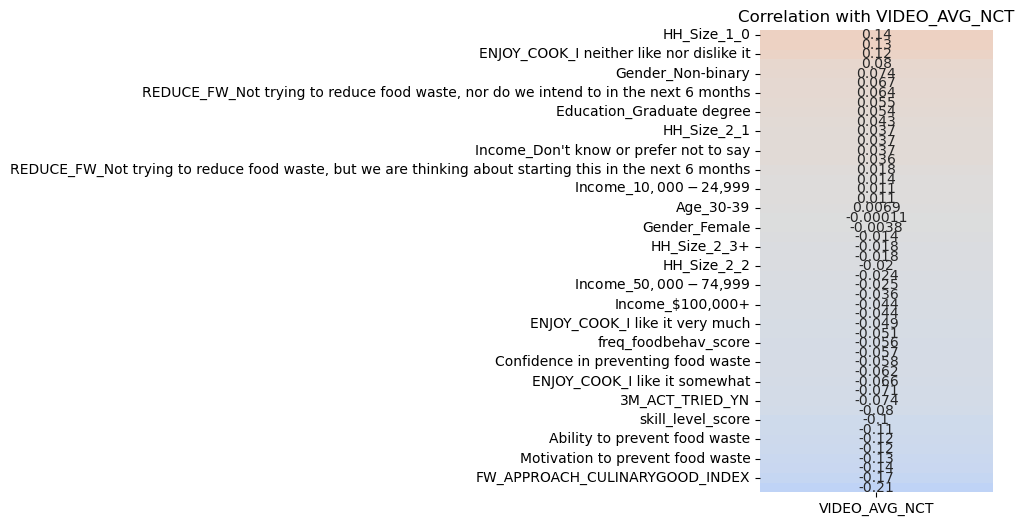

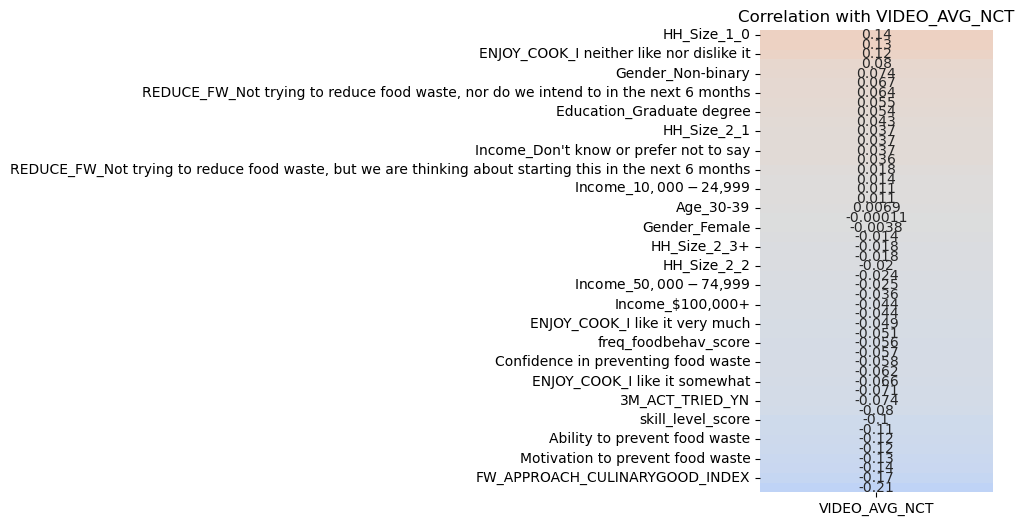

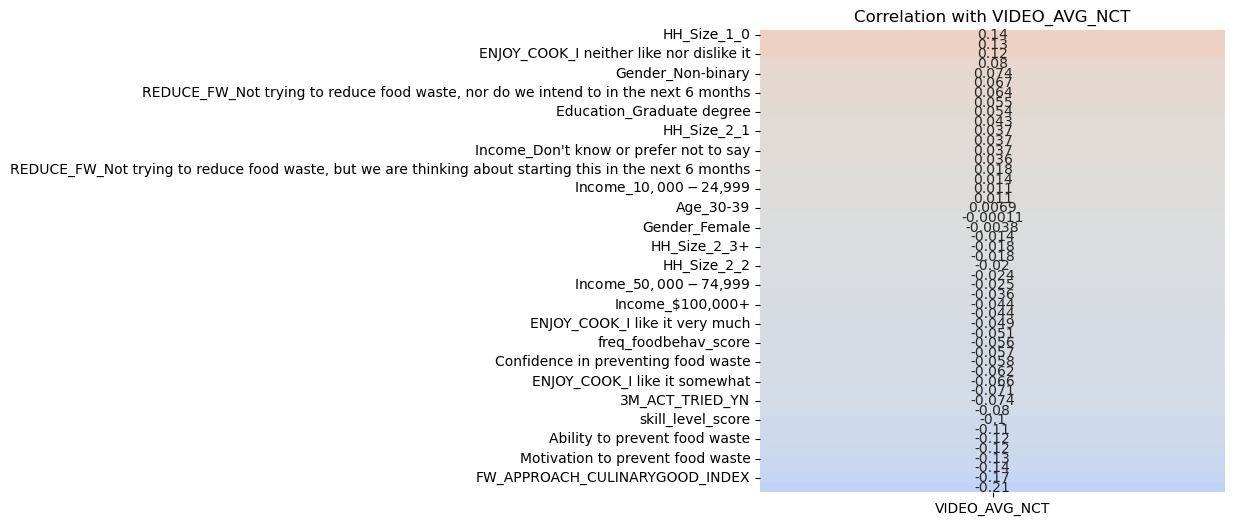

In [791]:
corr_cols = ['skill_level_score', 'freq_foodbehav_score', 'FW_APPROACH_CHEFHELPS_INDEX', 'FW_APPROACH_CULINARYGOOD_INDEX', 'VIDEO_AVG_NCT', '3M_ACT_TRIED_YN', '6M_ACT_TRIED_YN']


corr_df = df[corr_cols]
corr_df = pd.concat(
    [corr_df, age_dummies, income_dummies, educ_dummies, gender_dummies, Enjoy_cook_dummies, Reduce_fw_dummies, Impact_dummies_3m, hh_size_1_dummies, hh_size_2_dummies], axis = 1 
)

corr_df = corr_df.replace({True: 1, False: 0})
corr_df

# Correlation of everything with VIDEO_AVG_NCT
video_corr = corr_df.corr()[["VIDEO_AVG_NCT"]]
video_corr = video_corr.drop(labels=["VIDEO_AVG_NCT"])
video_corr = video_corr.sort_values(by="VIDEO_AVG_NCT", ascending=False)


if SHOW_PLOTS:
    plt.figure(figsize=(3, 6))
    sns.heatmap(video_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=False)
    plt.title("Correlation with VIDEO_AVG_NCT")
    plt.show()

# Correlation of everything with 3M_ACT_TRIED_YN
corr_3m = corr_df.corr()[['3M_ACT_TRIED_YN']]
corr_3m = corr_3m.drop(labels=['3M_ACT_TRIED_YN'])
corr_3m = corr_3m.sort_values(by='3M_ACT_TRIED_YN', ascending = False)


if SHOW_PLOTS:
    plt.figure(figsize=(3, 6))
    sns.heatmap(video_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=False)
    plt.title("Correlation with VIDEO_AVG_NCT")
    plt.show()

# Correlation of everything with 6M_ACT_TRIED_YN
corr_6m = corr_df.corr()[['6M_ACT_TRIED_YN']]
corr_6m = corr_6m.drop(labels=['6M_ACT_TRIED_YN'])
corr_6m = corr_6m.sort_values(by='6M_ACT_TRIED_YN', ascending = False)



if SHOW_PLOTS:
    plt.figure(figsize=(6, 6))
    sns.heatmap(video_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=False)
    plt.title("Correlation with VIDEO_AVG_NCT")
    plt.show()


## B: Regressions

What regression type to use?

In [792]:
df['3M_ACT_TRIED_YN'].value_counts()

3M_ACT_TRIED_YN
2.0    219
1.0    120
0.0     76
Name: count, dtype: int64

Since it's relatively balanced already, it doesn't really make sense to condense. <br>
I think the best way to look at this is probably ordinal logistic regression: [link to explanation](https://cscu.cornell.edu/wp-content/uploads/ordlogistic.pdf) <br>

### Model 1: Base Specification with only VIDEO_AVG_NCT and 3M_ACT_TRIED_YN

Need to check "proportional odds" assumption in order to use Ordinal Logistic Regression

This test does not exist easily in Python, so it it is easier to do it elsewhere supplementally. <br>

![Brant Test Output for First Model Specification](Images/Brant_Output_Model1.png)

Here the parallel regression assumption holds, and we can proceed with the model.

Since the DV will be ordinal, we should recode $\text{Never} \mapsto 0$, $\text{Once} \mapsto 1$, $\text{More than once} \mapsto 2$ (Already done to find the correlation)

Since the variable of interest is continuous but most of the other variables are binary, I am scaling the continuous ones

In [793]:
X = df['VIDEO_AVG_NCT'] 
Y = df['3M_ACT_TRIED_YN']

boolean_mask = ~pd.isnull(Y)
df_filtered = df[boolean_mask].reset_index(drop=True)
X = pd.DataFrame(
    StandardScaler().fit_transform(df_filtered[['VIDEO_AVG_NCT']]),
    columns=['VIDEO_AVG_NCT']
)

Y = df_filtered['3M_ACT_TRIED_YN'].astype(int).reset_index(drop=True)

Y = Y.astype(int)

export_df1 = pd.concat(
    [X, Y],
    axis=1
)

#ONLY FOR USE WHEN DOING TESTS IN R
#export_df1.to_csv('brant_model1_scaled.csv', index=True)

In [794]:
model = OrderedModel(
    Y,
    X,
    distr='logit'
)

results = model.fit(method='lbfgs')

if SHOW_PLOTS:
    print(results.summary())

                             OrderedModel Results                             
Dep. Variable:        3M_ACT_TRIED_YN   Log-Likelihood:                -417.23
Model:                   OrderedModel   AIC:                             840.5
Method:            Maximum Likelihood   BIC:                             852.5
Date:                Fri, 26 Jun 2026                                         
Time:                        11:01:30                                         
No. Observations:                 415                                         
Df Residuals:                     412                                         
Df Model:                           1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
VIDEO_AVG_NCT    -0.1109      0.096     -1.154      0.249      -0.299       0.077
0/1              -1.4936      0.127    -11.

How to interpret?<br>
 The coefficient on VIDEO_AVG_NCT is most important to look at, and it is not significant at the 5% alpha level.

The Odds Ratio tells you how much the odds of being in a higher category (trying more recommendations) when the average video score increases.<br> <br>
It is calculated as $e^{-\beta}$, so for average video score it is $e^{-0.1109}$ or about $0.9$, which means that the odds of being in the higher try category decrease by about 10% as the video average scores increase. (NOTE: BECAUSE OF THE WAY THE VIDEO SCORES ARE RECORDED, HIGHER -> Disagree More)

### Model 2: Adding in demographic variables:

First we have to drop something from each of the dummy rows to serve as a reference category <br>
I am making the choices here but they can be easily modified

Also, I am remaking the dummies on only the rows where 3M_ACT_TRIED is not null

In [795]:
df_filtered = df[boolean_mask].reset_index(drop=True)
Enjoy_cook_dummies = pd.get_dummies(
    df_filtered['enjoy_cook'],
    prefix='ENJOY_COOK'
)

Reduce_fw_dummies = pd.get_dummies(
    df_filtered['reduce_fw'],
    prefix='REDUCE_FW'
)

Impact_dummies_3m = df_filtered['3M_IMPACT'].str.get_dummies(sep=',')

age_dummies = pd.get_dummies(
    df_filtered['age'],
    prefix='Age'
)

age_dummies['Age_19-29'] = age_dummies['Age_19-21'] + age_dummies['Age_22-29']
age_dummies = age_dummies.drop(columns=['Age_19-21', 'Age_22-29'])

income_dummies = pd.get_dummies(
    df_filtered['income'],
    prefix='Income'
)

educ_dummies = pd.get_dummies(
    df_filtered['educ'],
    prefix='Education'
)

gender_dummies = pd.get_dummies(
    df_filtered['gender'],
    prefix='Gender'
)

hh_size_1_dummies = pd.get_dummies(
    df_filtered['hh_size_1'],
    prefix = 'HH_Size_1'
)

hh_size_2_dummies = pd.get_dummies(
    df_filtered['hh_size_2'],
    prefix = 'HH_Size_2'
)

In [796]:
income_dummies = income_dummies.drop(columns = ['Income_$50,000-$74,999'])
age_dummies = age_dummies.drop(columns=['Age_30-39'])
educ_dummies = educ_dummies.drop(columns = ['Education_High school graduate or GED'])
gender_dummies = gender_dummies.drop(columns = ['Gender_Male'])
hh_size_1_dummies = hh_size_1_dummies.drop(columns= ['HH_Size_1_0']) #No <16's
hh_size_2_dummies = hh_size_2_dummies.drop(columns = ['HH_Size_2_1']) #One person

scaler = StandardScaler()

video_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered[['VIDEO_AVG_NCT']]),
    columns=['VIDEO_AVG_NCT']
)


![Brant Test Output for Second Model Specification](Images/Brant_Output_Model2.png)

In [797]:
X = pd.concat(
    [video_scaled, age_dummies, income_dummies, educ_dummies, gender_dummies, hh_size_1_dummies, hh_size_2_dummies],
    axis=1
)

X = X.astype(float)

Y = df_filtered['3M_ACT_TRIED_YN'].reset_index(drop=True)


export_df2 = pd.concat(
    [X, Y],
    axis=1
)

#ONLY FOR USE WHEN DOING TESTS IN R
# export_df2.to_csv('brant_model2_scaled.csv', index=True)

In [798]:
model = OrderedModel(
    Y,
    X,
    distr='logit'
)

results = model.fit(method='lbfgs')

if SHOW_PLOTS:
    print(results.summary())

                             OrderedModel Results                             
Dep. Variable:        3M_ACT_TRIED_YN   Log-Likelihood:                -403.86
Model:                   OrderedModel   AIC:                             857.7
Method:            Maximum Likelihood   BIC:                             958.4
Date:                Fri, 26 Jun 2026                                         
Time:                        11:01:33                                         
No. Observations:                 415                                         
Df Residuals:                     390                                         
Df Model:                          23                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
VIDEO_AVG_NCT                             -0.0761      0.100     -0.759    

### Model 3: Seeing which additional variables are best to include

I will select the variables that add the most, using the AIC as the criterion. <br>

In [799]:
results = []

candidates = [
    'skill_level_score' , 'freq_foodbehav_score', 'FW_APPROACH_CULINARYGOOD_INDEX', 'FW_APPROACH_CHEFHELPS_INDEX'
]

X = X.reset_index(drop=True)
df_filtered = df[boolean_mask].reset_index(drop=True)
Y = Y.reset_index(drop=True)


for col in candidates:
    scaled = pd.DataFrame(
        StandardScaler().fit_transform(df_filtered[[col]]),
        columns=[col]
    )
    X_try = pd.concat([X, scaled], axis=1).astype(float)
    result = OrderedModel(Y, X_try, distr='logit').fit(method='lbfgs', disp=False)
    #print(f"{col}: AIC={result.aic:.2f}, p={result.pvalues[col]:.3f}")
    results.append({
    'variable': col,
    'type': 'continuous',
    'AIC': result.aic,
    'p': result.pvalues[col]
})

In [800]:
Impact_dummies_3m = Impact_dummies_3m.drop(columns=['Confidence in preventing food waste']) #using confidence as a reference, somewhat arbitrary but need to pick one
Impact_dummies_3m = Impact_dummies_3m.reset_index(drop=True)

Enjoy_cook_dummies = Enjoy_cook_dummies.drop(columns = 'ENJOY_COOK_I neither like nor dislike it') #using this as reference makes the most sense to me
Enjoy_cook_dummies = Enjoy_cook_dummies.reset_index(drop=True)

Reduce_fw_dummies = Reduce_fw_dummies.drop(columns= 'REDUCE_FW_Not trying to reduce food waste, nor do we intend to in the next 6 months') #again this made the most sense to be reference to me
Reduce_fw_dummies = Reduce_fw_dummies.reset_index(drop=True)

df_list = [Impact_dummies_3m, Enjoy_cook_dummies, Reduce_fw_dummies]

for dummy in df_list:
    X_try = pd.concat([X, dummy], axis=1).astype(float)
    result = OrderedModel(Y, X_try, distr='logit').fit(method='lbfgs', disp=False)
    #print(f"AIC: {result.aic:.2f}")
    #print(result.pvalues[dummy.columns]) 
    pvals = result.pvalues[dummy.columns] 
    results.append({
    'variable': ', '.join(dummy.columns.tolist()),
    'type': 'dummy',
    'AIC': result.aic,
    'p': pvals.min()  #report the lowest p-value for each *set* of dummy variables
})

In [801]:
results_df = pd.DataFrame(results).sort_values('AIC')
results_df

,variable,type,AIC,p
4,"Ability to prevent food waste, Interest in the...",dummy,825.822869,0.000010
6,"REDUCE_FW_Not trying to reduce food waste, but...",dummy,846.873168,0.017947
1,freq_foodbehav_score,continuous,849.762973,0.001559
5,"ENJOY_COOK_I dislike it somewhat, ENJOY_COOK_I...",dummy,852.373797,0.014753
0,skill_level_score,continuous,855.135635,0.032202
2,FW_APPROACH_CULINARYGOOD_INDEX,continuous,856.691499,0.080900
3,FW_APPROACH_CHEFHELPS_INDEX,continuous,858.743990,0.323891


Looks like the top 3 are some great candidates to add to the model, as they have the lowest AIC scores and significant p values (for the lowest p-value in the set if it's a dummy variable)

### Model with extra controls:

It might be good to get rid of some variables that don't seem to be very important, but a lot of the controls aren't strongly predictive. So it's not obvious which ones should be removed, at least to me.

In [802]:
scaled = pd.DataFrame(
        StandardScaler().fit_transform(df_filtered[['freq_foodbehav_score']]),
        columns=['freq_foodbehav_score']
    )

X = pd.concat(
    [X, Impact_dummies_3m, Reduce_fw_dummies, scaled],
    axis=1
)

X = X.astype(float)

Y = df_filtered['3M_ACT_TRIED_YN'].reset_index(drop=True)


export_df3 = pd.concat(
    [X, Y],
    axis=1
)

#ONLY FOR USE WHEN DOING TESTS IN R
# export_df3.to_csv('brant_model2_scaled.csv', index=True)

In [803]:
model = OrderedModel(
    Y,
    X,
    distr='logit'
)

results = model.fit(method='lbfgs')

if SHOW_PLOTS:
    print(results.summary())

                             OrderedModel Results                             
Dep. Variable:        3M_ACT_TRIED_YN   Log-Likelihood:                -376.03
Model:                   OrderedModel   AIC:                             818.1
Method:            Maximum Likelihood   BIC:                             951.0
Date:                Fri, 26 Jun 2026                                         
Time:                        11:01:54                                         
No. Observations:                 415                                         
Df Residuals:                     382                                         
Df Model:                          31                                         
                                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------

In [804]:
end = time.time()
t2 = end - start
print(f"Total runtime of Part III is {t2} seconds.")
print(f"Total notebook runtime: {t1 + t2} seconds.")

Total runtime of Part III is 30.00711154937744 seconds.
Total notebook runtime: 59.039706230163574 seconds.


Next steps: <br>
Re-run brant tests in R on updated data <br>
Try running the models where instead of deleting the 5's, add them in with the 1's <br>
Re-group some of the controls where some groups are close to 0, or make less sense based on the existing literature